Внимательно прочтите эти инструкции. Выполнение **всех** этих пунктов - обязательно для получения баллов за задание.

1) Проверка
    - После того, как вы допишете код
        - очистите все клетки (`Cell > All Output > Clear`)
        - выполните все клетки подряд (`Cell > Run All`)
    - Выполнение должно пройти без ошибок
    - Сохраните ноутбук с выполненными клетками

<!-- -->

2) Отправка в тестовую систему
    - Когда вы готовы сдать ноутбук, загрузите его в тестовую систему (fall.cv-gml.ru)
    - В тестовую систему нужно загружать только сам `.ipynb` ноутбук
        - Не нужно его `zip`овать
        - Не нужно его конвертировать в `pdf` или `html`
    - После загрузки в тестовую систему там появится ссылка для просмотра загруженного решения
        - Проверьте, что вы загрузили в тестовую систему то, что хотели
        - Проверьте, что в системе отображаются результаты выполнения всех клеток

## NeRF

Необходимо реализовать базовую версию [NeRF](https://arxiv.org/pdf/2003.08934.pdf) не включающую иерархический семплинг (его тоже можно реализовать, если есть желание). Код загрузки данных вам предоставлен, рекомендуется внимательно его изучить.

Работы оцениваются по бинарному принципу (зачет/незачет).

In [ ]:
%%bash

# Download dataset and helper library
for part in data lib; do
    if [ ! -d "${part}/" ]; then
        curl -sO "https://code.mipt.ru/courses-public/cv/storage/-/raw/tasks/neural-radiance-fields/${part}.zip"
        unzip -qo "${part}.zip"
    fi
done

# Install required dependencies
if ! pip freeze | grep -q nvdiffrast; then
    pip install -q \
        git+https://github.com/NVlabs/nvdiffrast.git \
        ninja xatlas trimesh \
        torch matplotlib
fi

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import nvdiffrast.torch as dr
import torch

glctx = dr.RasterizeCudaContext()

/home/evgenii-iurin/work/ITMO-3DCV/.venv312/lib/python3.12/site-packages/torch/utils/cpp_extension.py:2059: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


In [2]:
from lib.dataset import DatasetNERF

dataset = DatasetNERF(
    cfg="./data/hotdog/transforms_train.json",
    near=2.0,
    far=6.0,
    resolution=(160, 160),
    ray_mode=True,
)

In [3]:
def ray_gen(imv, coords, focal, resolution):
    """
    Необходимо реализовать функцию генерации лучей по заданным параметрам камеры

        @params: imv -- матрица 4x4, преобразование Camera Frame -> World Frame
        @params: coords -- координаты пикселя, coords[..., 0] - w, coords[..., 1] - h
        @params: focal -- фокальное расстояние камеры
        @params: resolution -- H, W разрешение

        Return: rays_o, rays_d -- положение и направление лучей
    """
    H, W = resolution
    N = coords.shape[0]
    device = coords.device

    coords = coords.float()

    x = (coords[:, 0] - W * 0.5) / focal
    y = -(coords[:, 1] - H * 0.5) / focal
    dirs = torch.stack([x, y, -torch.ones_like(x)], dim=-1)  # [N, 3]

    if imv.shape[0] == 1:
        R = imv[0, :3, :3].expand(N, -1, -1)
        T = imv[0, :3, 3].expand(N, 3)
    elif imv.shape[0] == N:
        R = imv[:, :3, :3]
        T = imv[:, :3, 3]
    else:
        raise ValueError(f"Incompatible shapes: imv.shape={imv.shape}, coords.shape={coords.shape}")

    rays_d = torch.bmm(R, dirs.unsqueeze(-1)).squeeze(-1)
    rays_o = T

    return rays_o.to(device), rays_d.to(device)

In [4]:
def ray_color(
    ray_o,
    ray_d,
    radiance_field_fn,
    near,
    far,
    bins,
    randomized=True,
):
    """
    Необходимо реализовать функцию рендеринга лучей, согласно уравнению NeRF'a: https://arxiv.org/pdf/2003.08934.pdf

        @params: ray_o, ray_d -- положение и направления луча
        @params: radiance_field_fn -- функция, возврашающая color, sigma
        @params: near, far -- диапазон семплирования вдоль лучей
        @params: bins -- количество точек для семплирования

        Return: color -- интегрированный по лучам свет
    """
    N = ray_o.shape[0]

    # 1. Семплирование точек вдоль лучей
    t_vals = torch.linspace(near, far, steps=bins, device=ray_o.device)  # [bins]
    t_vals = t_vals.expand(N, bins)  # [N, bins]

    if randomized:
        mids = 0.5 * (t_vals[:, :-1] + t_vals[:, 1:])  # [N, bins-1]
        upper = torch.cat([mids, t_vals[:, -1:]], dim=-1)
        lower = torch.cat([t_vals[:, :1], mids], dim=-1)
        t_rand = torch.rand(t_vals.shape, device=ray_o.device)  # [N, bins]
        t_vals = lower + (upper - lower) * t_rand  # jittered

    # 2. 3D-точки вдоль луча
    points = ray_o.unsqueeze(1) + ray_d.unsqueeze(1) * t_vals.unsqueeze(2)  # [N, bins, 3]
    dirs = ray_d[:, None, :].expand_as(points)  # [N, bins, 3]

    # 3. Пропускаем через модель
    points_flat = points.reshape(-1, 3)
    dirs_flat = dirs.reshape(-1, 3)
    colors, sigmas = radiance_field_fn(points_flat, dirs_flat)  # [N*bins, 3], [N*bins, 1]
    colors = colors.view(N, bins, 3)
    sigmas = sigmas.view(N, bins)

    # 4. Расчёт расстояний между точками
    deltas = t_vals[:, 1:] - t_vals[:, :-1]  # [N, bins-1]
    step = (far - near) / bins
    delta_last = torch.full_like(deltas[:, :1], fill_value=step)
    deltas = torch.cat([deltas, delta_last], dim=-1)


    # 5. Альфы (opacity)
    alphas = 1.0 - torch.exp(-sigmas * deltas)  # [N, bins]

    # 6. Накопленная прозрачность
    accum = torch.cumprod(
        torch.cat([torch.ones((N, 1), device=ray_o.device), 1.0 - alphas + 1e-10], dim=-1),
        dim=-1
    )[:, :-1]  # [N, bins]
    weights = alphas * accum  # [N, bins]

    # 7. Взвешенные цвета
    color = (weights.unsqueeze(-1) * colors).sum(dim=1)  # [N, 3]

    # color = color.clamp(0, 1)

    return color


In [5]:
from functools import partial

def render_radiance_field(
    imv,
    coords,
    radiance_field_fn,
    focal,
    resolution,
    near=2.0,
    far=6.0,
    bins=64,
    train=True,
    chunk=1024
):
    ray_gen_ = partial(
        ray_gen,
        focal=focal,
        resolution=resolution,
    )
    ray_color_ = partial(
        ray_color,
        radiance_field_fn=radiance_field_fn,
        near=near,
        far=far,
        bins=bins,
    )

    imv = (
        torch.tensor(imv, dtype=torch.float32, device="cuda")
        if not torch.is_tensor(imv)
        else imv
    )

    if train:
        ray_o, ray_d = ray_gen_(imv, coords)
        color = ray_color_(ray_o, ray_d)

        return color

    with torch.no_grad():
        H, W = resolution
        u, v = torch.meshgrid(
            torch.linspace(0, H - 1, H),
            torch.linspace(0, W - 1, W),
            indexing="ij",
        )

        coords = torch.stack([v.flatten(), u.flatten()], dim=-1)
        ray_o, ray_d = ray_gen_(imv[0:1, ...], coords)
        ray_o = ray_o.expand([ray_d.shape[0], -1])

        steps = ray_o.shape[0] // chunk + (ray_o.shape[0] % chunk > 0)

        ray_o = ray_o.to("cuda")
        ray_d = ray_d.to("cuda")

        color = torch.cat(
            [
                ray_color_(
                    ray_o[i * chunk : (i + 1) * chunk],
                    ray_d[i * chunk : (i + 1) * chunk],
                )
                for i in range(steps)
            ],
            dim=0,
        )
        return color.view(*resolution, 3).permute(1, 0, 2)

In [6]:
from torch import nn

class VanillaNeRF(nn.Module):
    def __init__(self, embedding_dim_pos=30, embedding_dim_direction=4, hidden_dim=256):
        super(VanillaNeRF, self).__init__()

        self.block1 = nn.Sequential(nn.Linear(embedding_dim_pos * 6 + 3, hidden_dim), nn.ReLU(),
                                    nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
                                    nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
                                    nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), )
        # density estimation
        self.block2 = nn.Sequential(nn.Linear(embedding_dim_pos * 6 + hidden_dim + 3, hidden_dim), nn.ReLU(),
                                    nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
                                    nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
                                    nn.Linear(hidden_dim, hidden_dim + 1), )
        # color estimation
        self.block3 = nn.Sequential(nn.Linear(embedding_dim_direction * 6 + hidden_dim + 3, hidden_dim // 2), nn.ReLU(), )
        self.block4 = nn.Sequential(nn.Linear(hidden_dim // 2, 3), nn.Sigmoid(), )
        # self.block4 = nn.Sequential(nn.Linear(hidden_dim // 2, 3))

        self.embedding_dim_pos = embedding_dim_pos
        self.embedding_dim_direction = embedding_dim_direction
        self.relu = nn.ReLU()

    @staticmethod
    def positional_encoding(x, L):
        out = [x]
        for j in range(L):
            out.append(torch.sin(2 ** j * x))
            out.append(torch.cos(2 ** j * x))
        return torch.cat(out, dim=1)

    def forward(self, o, d):
        emb_x = self.positional_encoding(o, self.embedding_dim_pos)
        emb_d = self.positional_encoding(d, self.embedding_dim_direction)
        h = self.block1(emb_x) 
        tmp = self.block2(torch.cat((h, emb_x), dim=1)) 
        h, sigma = tmp[:, :-1], self.relu(tmp[:, -1]) 
        h = self.block3(torch.cat((h, emb_d), dim=1)) 
        c = self.block4(h)

        return c, sigma


In [7]:
radiance_field = VanillaNeRF().cuda()
optimizer = torch.optim.Adam(list(radiance_field.parameters()), lr=5e-4)
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=2048,
    shuffle=True,
    collate_fn=dataset.collate,
)

In [10]:
import torch
import torch.nn.functional as F
from tqdm import tqdm

def train_nerf(
    radiance_field,
    optimizer,
    dataloader,
    render_fn,
    dataset,
    epochs=10,
    log_interval=100,
):
    radiance_field.train()

    for epoch in range(epochs):
        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")
        total_loss = 0

        for step, batch in enumerate(pbar):
            # Data is alrady with Batch size
            coords = batch["coords"]  # [2048, 2]
            target = batch["img"]     # [2048, 3]
            imv = batch["imv"]        # [2048, 4, 4]

            pred_rgb = render_fn(
                imv=imv,
                coords=coords,
                radiance_field_fn=radiance_field, # Model
                focal=dataset.focal,
                resolution=dataset.resolution,
                near=dataset.near,
                far=dataset.far,
                bins=256,
                train=True,
            )

            loss = F.mse_loss(pred_rgb, target)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pbar.set_postfix(loss=loss.item())

            if step % log_interval == 0:
                psnr = -10.0 * torch.log10(loss).item()
                print(f"[Epoch {epoch+1} | Step {step}] Loss: {loss.item():.4f} | PSNR: {psnr:.2f} dB")

        avg_loss = total_loss / len(dataloader)
        print(f"Epoch {epoch+1} finished. Avg loss: {avg_loss:.4f}")


In [ ]:
train_nerf(
    radiance_field=radiance_field,
    optimizer=optimizer,
    dataloader=dataloader,
    render_fn=render_radiance_field,
    dataset=dataset,
    epochs=1,
)


Epoch 1/1:   0%|          | 1/1250 [00:02<47:53,  2.30s/it, loss=0.0331]

[Epoch 1 | Step 0] Loss: 0.0331 | PSNR: 14.80 dB


Epoch 1/1:   8%|▊         | 101/1250 [02:25<31:20,  1.64s/it, loss=0.0115]

[Epoch 1 | Step 100] Loss: 0.0115 | PSNR: 19.41 dB


Epoch 1/1:  16%|█▌        | 201/1250 [05:03<17:11,  1.02it/s, loss=0.0089] 

...

[Epoch 1 | Step 1100] Loss: 0.0018 | PSNR: 27.35 dB


Epoch 1/1:  96%|█████████▌| 1201/1250 [22:27<00:47,  1.04it/s, loss=0.00186]

[Epoch 1 | Step 1200] Loss: 0.0019 | PSNR: 27.31 dB


Epoch 1/1: 100%|██████████| 1250/1250 [23:15<00:00,  1.12s/it, loss=0.0019] 

Epoch 1 finished. Avg loss: 0.0055


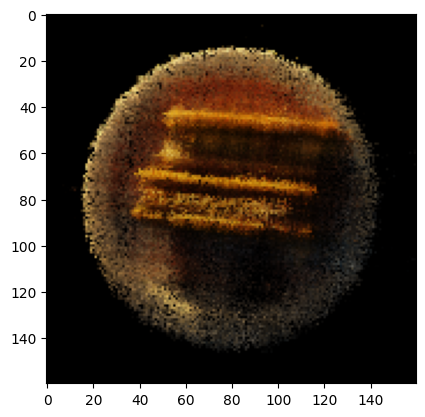

In [10]:
c = render_radiance_field(
    dataset[0]["imv"],
    None,
    radiance_field,
    dataset.focal,
    dataset.resolution,
    dataset.near,
    dataset.far,
    train=False,
)
plt.imshow(c.detach().cpu().numpy());

Ожидаемый результат (после первой эпохи):

<img src="https://code.mipt.ru/courses-public/cv/storage/-/raw/tasks/neural-radiance-fields/ref_epoch0.png" style="display: inline-block; text-align: left;"/>

```
epoch: 0, loss=0.002454527420923114
```

### Тренировка №1. 3 Эпохи

In [11]:
radiance_field = VanillaNeRF().cuda()
optimizer = torch.optim.Adam(list(radiance_field.parameters()), lr=5e-4)
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=2048,
    shuffle=True,
    collate_fn=dataset.collate,
)

train_nerf(
    radiance_field=radiance_field,
    optimizer=optimizer,
    dataloader=dataloader,
    render_fn=render_radiance_field,
    dataset=dataset,
    epochs=3,
)


Epoch 1/3:   0%|          | 1/1250 [00:01<31:13,  1.50s/it, loss=0.031]

[Epoch 1 | Step 0] Loss: 0.0310 | PSNR: 15.09 dB


Epoch 1/3:   8%|▊         | 101/1250 [02:57<31:10,  1.63s/it, loss=0.0136] 

[Epoch 1 | Step 100] Loss: 0.0136 | PSNR: 18.67 dB


Epoch 1/3:  16%|█▌        | 201/1250 [05:37<19:39,  1.12s/it, loss=0.00849]

...

[Epoch 3 | Step 1100] Loss: 0.0005 | PSNR: 33.30 dB


Epoch 3/3:  96%|█████████▌| 1201/1250 [30:23<01:20,  1.64s/it, loss=0.000371]

[Epoch 3 | Step 1200] Loss: 0.0004 | PSNR: 34.30 dB


Epoch 3/3: 100%|██████████| 1250/1250 [31:46<00:00,  1.53s/it, loss=0.000456]

Epoch 3 finished. Avg loss: 0.0006


### Промежуточный результат

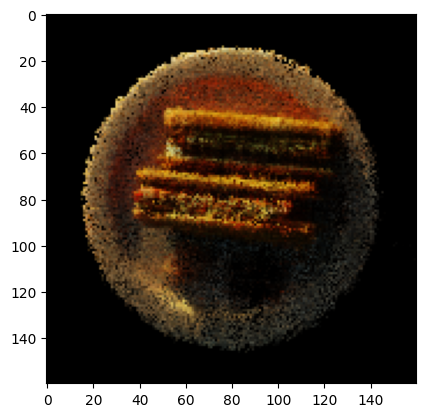

In [ ]:
c = render_radiance_field(
    dataset[0]["imv"],
    None,
    radiance_field,
    dataset.focal,
    dataset.resolution,
    dataset.near,
    dataset.far, 
    train=False,
)
plt.imshow(c.detach().cpu())

### Тренировка №2 / Лосс не опустился до нужного значения (достигнув  0.000456), поэтому решил сохранить веса и дотренировать

In [ ]:
from hw_4.model_io import save_trained_model

save_path = save_trained_model(
    model=radiance_field,
    optimizer=optimizer,  # Optional
    loss=0.000456,  # Optional - your final loss value if you have it
    save_dir="models",
    filename="loss-0.000456-best.pth"  
)

print(f"Model saved to: {save_path}")


In [12]:
from model_io import load_checkpoint

checkpoint_path = "models/loss-0.000456-best.pth"
radiance_field = VanillaNeRF().cuda()
optimizer = torch.optim.Adam(list(radiance_field.parameters()), lr=5e-4)
radiance_field, optimizer, start_epoch, best_loss = load_checkpoint(
    checkpoint_path, 
    model_class=VanillaNeRF, 
    optimizer=optimizer
)
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=2048,
    shuffle=True,
    collate_fn=dataset.collate,
)




In [13]:
print(f"Resuming from epoch {start_epoch} with loss {best_loss}")

# Continue training
train_nerf(
    radiance_field=radiance_field,
    optimizer=optimizer,
    dataloader=dataloader,
    render_fn=render_radiance_field,
    dataset=dataset,
    epochs=3
    )

Resuming from epoch 0 with loss 0.000456


Epoch 1/3:   0%|          | 1/1250 [00:01<33:30,  1.61s/it, loss=0.00032]

[Epoch 1 | Step 0] Loss: 0.0003 | PSNR: 34.94 dB


Epoch 1/3:   8%|▊         | 101/1250 [01:42<15:35,  1.23it/s, loss=0.00035]

[Epoch 1 | Step 100] Loss: 0.0004 | PSNR: 34.56 dB


...

[Epoch 3 | Step 1100] Loss: 0.0004 | PSNR: 34.46 dB


Epoch 3/3:  96%|█████████▌| 1200/1250 [20:31<01:00,  1.22s/it, loss=0.000377]

[Epoch 3 | Step 1200] Loss: 0.0004 | PSNR: 34.24 dB


Epoch 3/3: 100%|██████████| 1250/1250 [21:25<00:00,  1.03s/it, loss=0.000434]

Epoch 3 finished. Avg loss: 0.0004


### Финальный результат

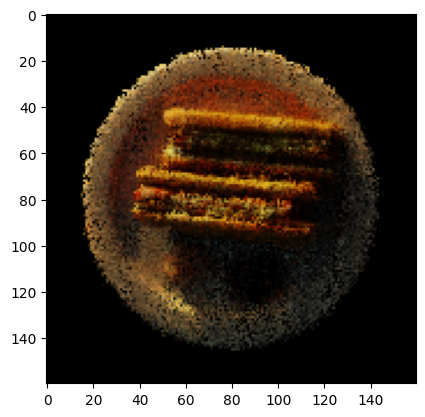

In [14]:
c = render_radiance_field(
    dataset[0]["imv"],
    None,
    radiance_field,
    dataset.focal,
    dataset.resolution,
    dataset.near,
    dataset.far, 
    train=False,
)
plt.imshow(c.detach().cpu())

Ожидаемый результат (после обучения):

<img src="https://code.mipt.ru/courses-public/cv/storage/-/raw/tasks/neural-radiance-fields/ref_final.png" style="display: inline-block; text-align: left;"/>

```
loss=0.00013125527766533196
```

### Debug functions (added for debug purposes only)

In [ ]:
# ### OVERFIT ON ONE PIXEL (NETWORK HEALTH CHECK)


# import torch
# import torch.nn.functional as F
# from tqdm import tqdm

# def overfit_on_one_pixel(radiance_field, optimizer, dataset, steps=2000, coord=(80, 80)):
#     example = dataset[1212] # this pixel has the color

#     imv = example["imv"].cuda()
#     coords = example["coords"].cuda()
#     gt_color = example["img"].cuda()  # [1, 3], т.к. H, W в image

#     print(f"Целевой цвет пикселя {coord}:", gt_color.cpu().numpy())

#     pbar = tqdm(range(steps))
#     for step in pbar:
#         pred_rgb = render_radiance_field(
#             imv=imv,
#             coords=coords,
#             radiance_field_fn=radiance_field,
#             focal=dataset.focal,
#             resolution=dataset.resolution,
#             near=dataset.near,
#             far=dataset.far,
#             bins=64,
#             train=True,
#         )

#         loss = F.mse_loss(pred_rgb, gt_color)
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         if step % 100 == 0:
#             psnr = -10 * torch.log10(loss).item()
#             print(f"[Step {step}] Loss: {loss.item():.6f} | PSNR: {psnr:.2f} dB")

#     print("pred_rgb.detach().cpu().numpy())

# radiance_field = VanillaNeRF().cuda()
# optimizer = torch.optim.Adam(radiance_field.parameters(), lr=1e-3)

# overfit_on_one_pixel(radiance_field, optimizer, dataset, steps=2000, coord=(80, 80))


In [ ]:
# ### OVERFIT ON ONE IMAGE (MODEL CHECK)
# import torch
# import torch.nn.functional as F
# from tqdm import tqdm

# from lib.dataset import DatasetNERF

# dataset = DatasetNERF(
#     cfg="./data/hotdog/transforms_train.json",
#     near=2.0,
#     far=6.0,
#     resolution=(160, 160),
#     ray_mode=False,
# )


# def overfit_on_one_image(
#     radiance_field,
#     optimizer,
#     dataset,
#     steps=3000,
#     image_index=0,
#     resolution=None
# ):
#     example = dataset[image_index]  # ray_mode=False
#     imv = example["imv"].cuda()
#     gt_img = example["img"][0].cuda()  # [H, W, 3]

#     if resolution is None:
#         H, W = dataset.resolution
#     else:
#         H, W = resolution

#     # Генерация всех координат (w, h)
#     u, v = torch.meshgrid(
#         torch.linspace(0, H - 1, H),
#         torch.linspace(0, W - 1, W),
#         indexing="ij"
#     )
#     coords = torch.stack([v.flatten(), u.flatten()], dim=-1).cuda()  # [H*W, 2]
#     gt_img_flat = gt_img.view(-1, 3)  # [H*W, 3]

#     print("image_index, "with resolution", H, W)

#     pbar = tqdm(range(steps))
#     for step in pbar:
#         pred_rgb = render_radiance_field(
#             imv=imv,
#             coords=coords,
#             radiance_field_fn=radiance_field,
#             focal=dataset.focal,
#             resolution=(H, W),
#             near=dataset.near,
#             far=dataset.far,
#             bins=64,
#             train=True,
#         )

#         loss = F.mse_loss(pred_rgb, gt_img_flat)
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         if step % 100 == 0:
#             psnr = -10 * torch.log10(loss).item()
#             print(f"[Step {step}] Loss: {loss.item():.6f} | PSNR: {psnr:.2f} dB")


#     with torch.no_grad():
#         final_img = render_radiance_field(
#             imv=imv,
#             coords=None,
#             radiance_field_fn=radiance_field,
#             focal=dataset.focal,
#             resolution=(H, W),
#             near=dataset.near,
#             far=dataset.far,
#             bins=64,
#             train=False,
#         ).clamp(0, 1)

#     return final_img, gt_img


# radiance_field = VanillaNeRF().cuda()
# optimizer = torch.optim.Adam(radiance_field.parameters(), lr=1e-3)

# final_img, gt_img = overfit_on_one_image(
#     radiance_field,
#     optimizer,
#     dataset,
#     steps=2000,
#     image_index=0
# )
